In [ ]:
# ============================================
# PREPROCESSING PIPELINE
# ============================================
# CELL 1: Setup Environment
# ============================================

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import wandb
import json
from datetime import datetime

print(f"✅ PyTorch version: {torch.__version__}")
print(f"✅ CUDA available: {torch.cuda.is_available()}")



✅ PyTorch version: 2.9.0+cu126
✅ CUDA available: True


In [ ]:
# ============================================
# CELL 2: Initialize WandB
# ============================================
wandb.login()

wandb.init(
    project="fl-pneumonia-detection",
    name="day3-preprocessing-pipeline",
    config={
        "phase": "preprocessing",
        "week": 1,
        "day": 3,
        "image_size": 224,
        "batch_size": 32,
        "normalization": "imagenet"
    }
)

print("✅ WandB initialized!")



/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Find your API key here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: chiwa-vw (chiwa-vw-personal) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


✅ WandB initialized!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_ROOT = '/content/drive/MyDrive/FL-Pneumonia-Detection'
os.chdir(PROJECT_ROOT)
print(f"✅ Working directory: {os.getcwd()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Working directory: /content/drive/MyDrive/FL-Pneumonia-Detection


In [ ]:
# ============================================
# CELL 3: Define Paths
# ============================================
DATA_RAW = os.path.join(PROJECT_ROOT, 'data/raw')
DATA_PROCESSED = os.path.join(PROJECT_ROOT, 'data/processed')
UTILS_DIR = os.path.join(PROJECT_ROOT, 'utils')
RESULTS_DIR = os.path.join(PROJECT_ROOT, 'results')

os.makedirs(UTILS_DIR, exist_ok=True)

# Data location (nested chest_xray folder)
CHEST_XRAY_DIR = os.path.join(DATA_RAW, 'chest_xray', 'chest_xray')

print(f"📂 Data: {CHEST_XRAY_DIR}")
assert os.path.exists(CHEST_XRAY_DIR), f"Data not found!"
print("✅ Paths verified!")


📂 Data: /content/drive/MyDrive/FL-Pneumonia-Detection/data/raw/chest_xray/chest_xray
✅ Paths verified!


In [ ]:
# ============================================
# CELL 4: Preprocessing Configuration
# ============================================
PREPROCESSING_CONFIG = {
    "image_size": 224,
    "image_channels": 3,
    "mean": [0.485, 0.456, 0.406],  # ImageNet stats
    "std": [0.229, 0.224, 0.225],
    "augmentation": {
        "rotation_degrees": 15,
        "horizontal_flip": True,
        "vertical_flip": False,
        "brightness": 0.2,
        "contrast": 0.2,
    },
    "batch_size": 32,
    "num_workers": 2,
    "pin_memory": True,
    "class_to_idx": {"NORMAL": 0, "PNEUMONIA": 1}
}

# Save config
config_path = os.path.join(UTILS_DIR, 'preprocessing_config.json')
with open(config_path, 'w') as f:
    json.dump(PREPROCESSING_CONFIG, f, indent=2)

print("✅ Config saved!")
wandb.config.update(PREPROCESSING_CONFIG)


✅ Config saved!


In [ ]:
# ============================================
# CELL 5: Define Transforms
# ============================================
def get_train_transforms(config):
    return transforms.Compose([
        transforms.Resize((config["image_size"], config["image_size"])),
        transforms.RandomRotation(config["augmentation"]["rotation_degrees"]),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ColorJitter(
            brightness=config["augmentation"]["brightness"],
            contrast=config["augmentation"]["contrast"]
        ),
        transforms.ToTensor(),
        transforms.Normalize(mean=config["mean"], std=config["std"])
    ])

def get_val_test_transforms(config):
    return transforms.Compose([
        transforms.Resize((config["image_size"], config["image_size"])),
        transforms.ToTensor(),
        transforms.Normalize(mean=config["mean"], std=config["std"])
    ])

train_transforms = get_train_transforms(PREPROCESSING_CONFIG)
val_transforms = get_val_test_transforms(PREPROCESSING_CONFIG)
test_transforms = get_val_test_transforms(PREPROCESSING_CONFIG)

print("✅ Transforms created!")

✅ Transforms created!


In [ ]:
# ============================================
# CELL 6: Custom Dataset Class
# ============================================
class ChestXrayDataset(Dataset):
    def __init__(self, data_dir, split='train', transform=None):
        self.data_dir = data_dir
        self.split = split
        self.transform = transform
        self.images = []
        self.labels = []

        split_dir = os.path.join(data_dir, split)

        # Load NORMAL images (label = 0)
        normal_dir = os.path.join(split_dir, 'NORMAL')
        if os.path.exists(normal_dir):
            for img_name in os.listdir(normal_dir):
                if img_name.endswith(('.jpeg', '.jpg', '.png')):
                    self.images.append(os.path.join(normal_dir, img_name))
                    self.labels.append(0)

        # Load PNEUMONIA images (label = 1)
        pneumonia_dir = os.path.join(split_dir, 'PNEUMONIA')
        if os.path.exists(pneumonia_dir):
            for img_name in os.listdir(pneumonia_dir):
                if img_name.endswith(('.jpeg', '.jpg', '.png')):
                    self.images.append(os.path.join(pneumonia_dir, img_name))
                    self.labels.append(1)

        print(f"📊 {split.upper()}: {len(self.images)} images")
        print(f"   NORMAL: {self.labels.count(0)}, PNEUMONIA: {self.labels.count(1)}")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = Image.open(self.images[idx]).convert('RGB')
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label

    def get_class_distribution(self):
        normal_count = self.labels.count(0)
        pneumonia_count = self.labels.count(1)
        return {
            'NORMAL': normal_count,
            'PNEUMONIA': pneumonia_count,
            'ratio': pneumonia_count / normal_count if normal_count > 0 else 0
        }

print("✅ Dataset class defined!")

✅ Dataset class defined!


In [ ]:
# ============================================
# CELL 7: Create Datasets
# ============================================
train_dataset = ChestXrayDataset(CHEST_XRAY_DIR, 'train', train_transforms)
val_dataset = ChestXrayDataset(CHEST_XRAY_DIR, 'val', val_transforms)
test_dataset = ChestXrayDataset(CHEST_XRAY_DIR, 'test', test_transforms)

train_dist = train_dataset.get_class_distribution()
val_dist = val_dataset.get_class_distribution()
test_dist = test_dataset.get_class_distribution()

print("\n" + "="*60)
print("📊 DATASET SUMMARY")
print("="*60)
print(f"Train: {len(train_dataset)} (ratio: {train_dist['ratio']:.2f}:1)")
print(f"Val:   {len(val_dataset)} (ratio: {val_dist['ratio']:.2f}:1)")
print(f"Test:  {len(test_dataset)} (ratio: {test_dist['ratio']:.2f}:1)")
print("="*60)

wandb.log({
    "train_size": len(train_dataset),
    "val_size": len(val_dataset),
    "test_size": len(test_dataset),
    "train_imbalance_ratio": train_dist['ratio']
})

📊 TRAIN: 5216 images
   NORMAL: 1341, PNEUMONIA: 3875
📊 VAL: 16 images
   NORMAL: 8, PNEUMONIA: 8
📊 TEST: 624 images
   NORMAL: 234, PNEUMONIA: 390

📊 DATASET SUMMARY
Train: 5216 (ratio: 2.89:1)
Val:   16 (ratio: 1.00:1)
Test:  624 (ratio: 1.67:1)


In [ ]:
# ============================================
# CELL 8: Create DataLoaders
# ============================================
train_loader = DataLoader(
    train_dataset,
    batch_size=PREPROCESSING_CONFIG["batch_size"],
    shuffle=True,
    num_workers=PREPROCESSING_CONFIG["num_workers"],
    pin_memory=PREPROCESSING_CONFIG["pin_memory"]
)

val_loader = DataLoader(
    val_dataset,
    batch_size=PREPROCESSING_CONFIG["batch_size"],
    shuffle=False,
    num_workers=PREPROCESSING_CONFIG["num_workers"],
    pin_memory=PREPROCESSING_CONFIG["pin_memory"]
)

test_loader = DataLoader(
    test_dataset,
    batch_size=PREPROCESSING_CONFIG["batch_size"],
    shuffle=False,
    num_workers=PREPROCESSING_CONFIG["num_workers"],
    pin_memory=PREPROCESSING_CONFIG["pin_memory"]
)

print("✅ DataLoaders created!")
print(f"\n📦 Batches: Train={len(train_loader)}, Val={len(val_loader)}, Test={len(test_loader)}")


✅ DataLoaders created!

📦 Batches: Train=163, Val=1, Test=20


In [ ]:
# ============================================
# CELL 9: Test Pipeline
# ============================================
sample_images, sample_labels = next(iter(train_loader))

print("\n🧪 Pipeline Test:")
print(f"   Batch shape: {sample_images.shape}")
print(f"   Labels shape: {sample_labels.shape}")
print(f"   Min: {sample_images.min():.3f}, Max: {sample_images.max():.3f}")
print(f"   Mean: {sample_images.mean():.3f}, Std: {sample_images.std():.3f}")

assert sample_images.shape == (32, 3, 224, 224), "Shape mismatch!"
print("\n✅ Pipeline test passed!")


🧪 Pipeline Test:
   Batch shape: torch.Size([32, 3, 224, 224])
   Labels shape: torch.Size([32])
   Min: -2.118, Max: 2.640
   Mean: 0.103, Std: 1.149

✅ Pipeline test passed!


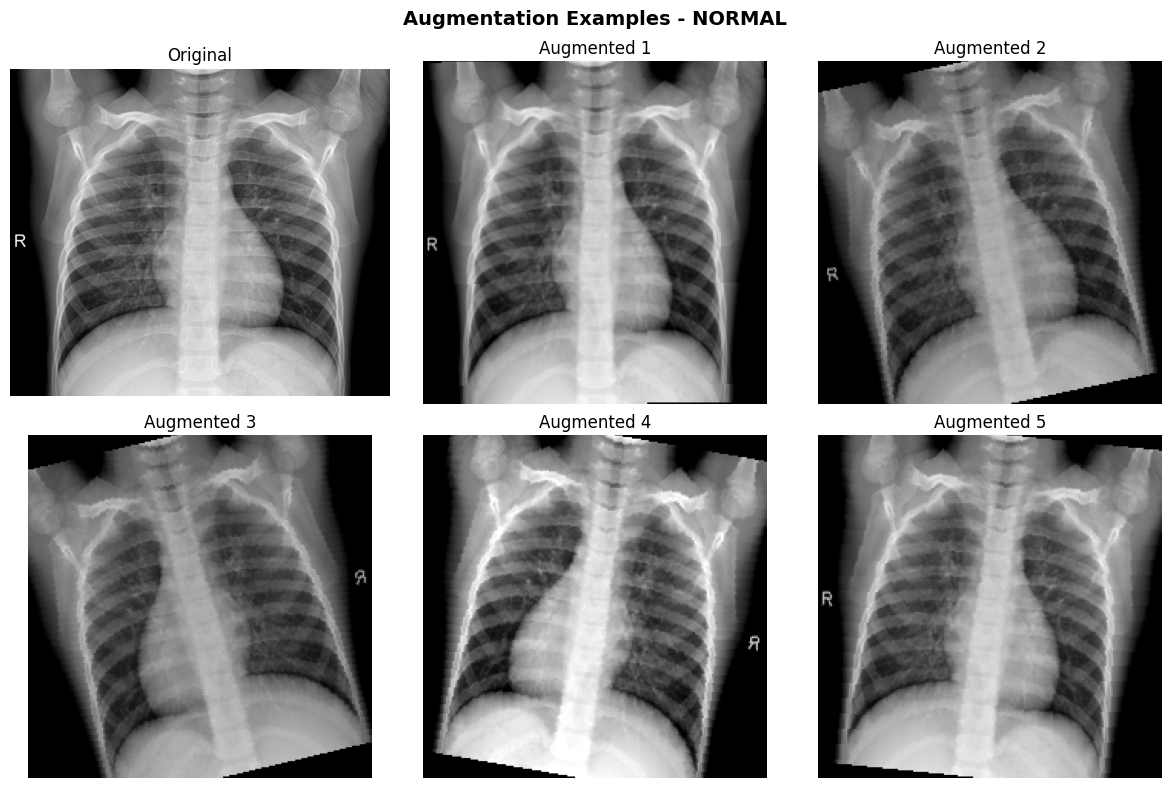

✅ Augmentation visualization complete!


In [ ]:
# ============================================
# CELL 10: Visualize Augmentation
# ============================================
def denormalize(tensor, mean, std):
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)
    return tensor

# Get one image
idx = 0
original_img = Image.open(train_dataset.images[idx]).convert('RGB')
label = "PNEUMONIA" if train_dataset.labels[idx] == 1 else "NORMAL"

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
fig.suptitle(f"Augmentation Examples - {label}", fontsize=14, fontweight='bold')

# Original
axes[0, 0].imshow(original_img)
axes[0, 0].set_title("Original")
axes[0, 0].axis('off')

# Show 5 augmented versions
for i in range(5):
    row = (i + 1) // 3
    col = (i + 1) % 3

    augmented = train_transforms(original_img)
    augmented_display = denormalize(
        augmented.clone(),
        PREPROCESSING_CONFIG["mean"],
        PREPROCESSING_CONFIG["std"]
    )

    img_np = augmented_display.permute(1, 2, 0).numpy()
    img_np = np.clip(img_np, 0, 1)

    axes[row, col].imshow(img_np)
    axes[row, col].set_title(f"Augmented {i+1}")
    axes[row, col].axis('off')

plt.tight_layout()
wandb.log({"augmentation_examples": wandb.Image(fig)})
plt.show()
print("✅ Augmentation visualization complete!")

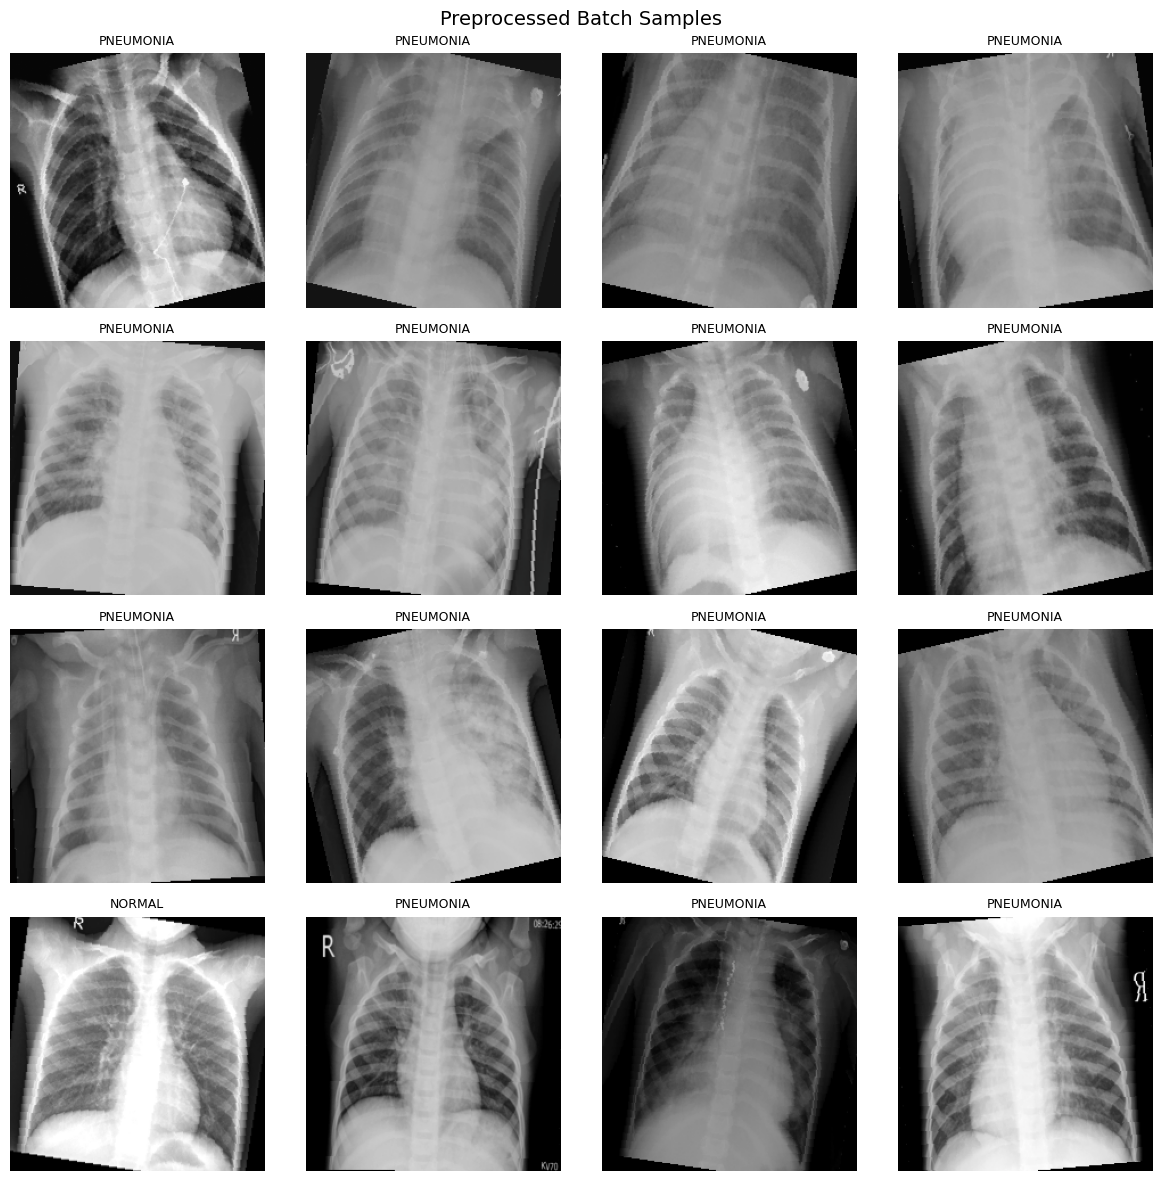

✅ Batch visualization complete!


In [ ]:
# ============================================
# CELL 11: Visualize Batch
# ============================================
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
fig.suptitle("Preprocessed Batch Samples", fontsize=14)

for idx in range(16):
    row, col = idx // 4, idx % 4

    img = denormalize(
        sample_images[idx].clone(),
        PREPROCESSING_CONFIG["mean"],
        PREPROCESSING_CONFIG["std"]
    )

    img_np = img.permute(1, 2, 0).numpy()
    img_np = np.clip(img_np, 0, 1)

    axes[row, col].imshow(img_np)
    label_name = "PNEUMONIA" if sample_labels[idx].item() == 1 else "NORMAL"
    axes[row, col].set_title(label_name, fontsize=9)
    axes[row, col].axis('off')

plt.tight_layout()
wandb.log({"preprocessed_batch": wandb.Image(fig)})
plt.show()
print("✅ Batch visualization complete!")

In [ ]:
# ============================================
# CELL 12: Calculate Class Weights
# ============================================
def calculate_class_weights(dataset):
    dist = dataset.get_class_distribution()
    total = dist['NORMAL'] + dist['PNEUMONIA']

    weight_normal = total / (2 * dist['NORMAL'])
    weight_pneumonia = total / (2 * dist['PNEUMONIA'])

    return torch.tensor([weight_normal, weight_pneumonia], dtype=torch.float32)

class_weights = calculate_class_weights(train_dataset)

print("\n⚖️  Class Weights:")
print(f"   NORMAL: {class_weights[0]:.4f}")
print(f"   PNEUMONIA: {class_weights[1]:.4f}")

weights_path = os.path.join(UTILS_DIR, 'class_weights.pt')
torch.save(class_weights, weights_path)
print(f"\n✅ Weights saved to: {weights_path}")

wandb.log({
    "class_weight_normal": class_weights[0].item(),
    "class_weight_pneumonia": class_weights[1].item()
})


⚖️  Class Weights:
   NORMAL: 1.9448
   PNEUMONIA: 0.6730

✅ Weights saved to: /content/drive/MyDrive/FL-Pneumonia-Detection/utils/class_weights.pt


In [ ]:
# ============================================
# CELL 13: Save Utility Module
# ============================================
preprocessing_utils = '''"""
Preprocessing utilities for FL Pneumonia Detection
"""
import torch
from torch.utils.data import Dataset
import torchvision.transforms as transforms
from PIL import Image
import os
import json

with open('utils/preprocessing_config.json', 'r') as f:
    CONFIG = json.load(f)

def get_train_transforms():
    return transforms.Compose([
        transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
        transforms.RandomRotation(CONFIG["augmentation"]["rotation_degrees"]),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ColorJitter(brightness=CONFIG["augmentation"]["brightness"],
                              contrast=CONFIG["augmentation"]["contrast"]),
        transforms.ToTensor(),
        transforms.Normalize(mean=CONFIG["mean"], std=CONFIG["std"])
    ])

def get_val_test_transforms():
    return transforms.Compose([
        transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
        transforms.ToTensor(),
        transforms.Normalize(mean=CONFIG["mean"], std=CONFIG["std"])
    ])

class ChestXrayDataset(Dataset):
    def __init__(self, data_dir, split='train', transform=None):
        self.images, self.labels = [], []
        split_dir = os.path.join(data_dir, split)

        for class_name, label in [('NORMAL', 0), ('PNEUMONIA', 1)]:
            class_dir = os.path.join(split_dir, class_name)
            if os.path.exists(class_dir):
                for img_name in os.listdir(class_dir):
                    if img_name.endswith(('.jpeg', '.jpg', '.png')):
                        self.images.append(os.path.join(class_dir, img_name))
                        self.labels.append(label)
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = Image.open(self.images[idx]).convert('RGB')
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label

def load_class_weights():
    return torch.load('utils/class_weights.pt')
'''

utils_path = os.path.join(UTILS_DIR, 'preprocessing.py')
with open(utils_path, 'w') as f:
    f.write(preprocessing_utils)

print(f"✅ Utils saved to: {utils_path}")

✅ Utils saved to: /content/drive/MyDrive/FL-Pneumonia-Detection/utils/preprocessing.py


In [ ]:
# ============================================
# CELL 14: Summary
# ============================================
summary = {
    "date": datetime.now().strftime("%Y-%m-%d"),
    "week": 1,
    "day": 3,
    "milestone": "Preprocessing Pipeline Complete",
    "datasets": {
        "train": {"total": len(train_dataset), **train_dist},
        "val": {"total": len(val_dataset), **val_dist},
        "test": {"total": len(test_dataset), **test_dist}
    },
    "artifacts_created": [
        "utils/preprocessing_config.json",
        "utils/preprocessing.py",
        "utils/class_weights.pt"
    ]
}

summary_path = os.path.join(RESULTS_DIR, 'day3_summary.json')
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)

print("\n" + "="*60)
print("🎉 DAY 3 COMPLETE!")
print("="*60)
print(f"\nTrain: {len(train_dataset)} images")
print(f"Val: {len(val_dataset)} images")
print(f"Test: {len(test_dataset)} images")
print(f"Class weights: NORMAL={class_weights[0]:.3f}, PNEUMONIA={class_weights[1]:.3f}")
print(f"\n✅ Next: Day 4 - Data Partitioning")
print("="*60)

wandb.finish()


🎉 DAY 3 COMPLETE!

Train: 5216 images
Val: 16 images
Test: 624 images
Class weights: NORMAL=1.945, PNEUMONIA=0.673

✅ Next: Day 4 - Data Partitioning


class_weight_normal,▁
class_weight_pneumonia,▁
test_size,▁
train_imbalance_ratio,▁
train_size,▁
val_size,▁
class_weight_normal,1.94482
class_weight_pneumonia,0.67303
test_size,624
train_imbalance_ratio,2.88963
train_size,5216
